In [2]:
import matplotlib.image as mpimg
import matplotlib.pyplot as plt
import numpy as np
from PIL import Image
import scipy.ndimage as ndimage

## Effect 1: Blue print

In [3]:
def mag_sobel(img: np.ndarray) -> np.ndarray:
    Sh = np.array([[1, 0, -1], [2, 0, -2], [1, 0, -1]])
    Sv = np.array([[1, 2, 1], [0, 0, 0], [-1, -2, -1]])

    img = img.astype(np.float32)
    img_h = ndimage.convolve(img, Sh)
    img_v = ndimage.convolve(img, Sv)
    return np.sqrt(np.power(img_h, 2) + np.power(img_v, 2))

In [ ]:
def halftoning_effect(img: np.ndarray, block_size: int = 3) -> np.ndarray:
    """Aplica um efeito suave de halftoning criando uma malha de pontos.
    
    Args:
        img (np.ndarray): Imagem de entrada. Precisa estar no intervalo [0, 1] para os cálculos!
        block_size (int): Tamanho do bloco para a malha de halftoning.

    Returns:
        np.ndarray: Imagem com o efeito de halftoning aplicado. Imagem resultante estará no intervalo [0, 1].
    """
        
    h, w = img.shape[:2]
    y, x = np.meshgrid(np.arange(h), np.arange(w), indexing='ij')
    pattern = (np.sin(x * np.pi / block_size) * np.sin(y * np.pi / block_size) + 1.0) / 2.0
    
    # Expandir para ter canais como a imagem
    if img.ndim == 3:
        pattern = pattern[..., np.newaxis]
        
    # Combina a intensidade original com o padrão para texturizar
    return np.clip(img * (0.5 + 0.5 * pattern), 0, 1)

def rgb_to_grayscale(rgb: np.ndarray) -> np.ndarray:
    """Converte uma imagem RGB para escala de cinza usando a fórmula de luminosidade.
    
    Args:
        rgb (np.ndarray): Imagem RGB de entrada. Deve ter forma (H, W, 3) e valores no intervalo [0, 1].
    
    Returns:
        np.ndarray: Imagem em escala de cinza resultante, com forma (H, W) e valores no intervalo [0, 1].
    """
    return np.dot(rgb[..., :3], [0.2989, 0.5870, 0.1140])

def blueprint_effect(image: np.ndarray) -> np.ndarray:
    if image.ndim == 3 and image.shape[-1] >= 3:
        gray = rgb_to_grayscale(image)
    else:
        gray = image.copy()

    # Detecção de borda
    edges = mag_sobel(gray)
    edges = edges / np.max(edges)
    
    # Thresholding e Dilatação para clarear e tornar as linhas mais espessas/visíveis
    edges = np.where(edges > 0.1, edges, 0.0)
    edges = ndimage.maximum_filter(edges, size=5)
    
    # Mapeamento de cores (um tom de azul e um de branco)
    blue_bg = np.array([25, 84, 166]) / 255.0   # Fundo azul
    white_lines = np.array([255, 255, 255]) / 255.0 # Linhas brancas
    
    edges_expanded = edges[..., np.newaxis]
    blueprint = (edges_expanded * white_lines) + ((1.0 - edges_expanded) * blue_bg)
    
    # Aplica textura/halftoning simulando papel impresso
    blueprint_textured = halftoning_effect(blueprint, block_size=15)
    
    return np.clip(blueprint_textured, 0, 1)

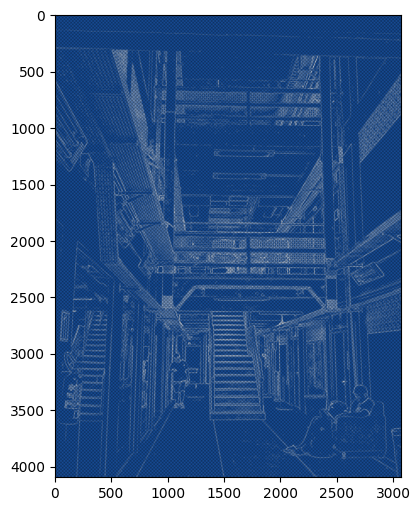

In [30]:
staircase_img = mpimg.imread('../../photo/257234_escadas.jpg')
staircase_img_bp = blueprint_effect(staircase_img)
plt.figure(figsize=(12, 6))
plt.imshow(staircase_img_bp)

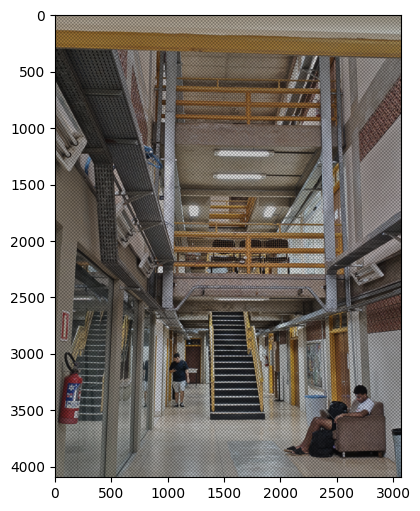

In [ ]:
img = halftoning_effect(staircase_img, block_size=15)
img = np.clip(img, 0, 1)
plt.figure(figsize=(12, 6))
plt.imshow(img)